# Discount analysis
___
This report shows the use of the discount tool in license sales.


In [1]:
from make_chart import make_chart
from working_with_db import *
from printmd import *

conn = connect_to_local_postgresql(db_name='postgres', user='jet', password='brains')

customer_status = ['new customer',
                   'existing customer: new product use',
                   'existing customer: renewal',
                   'existing customer: additional new licenses']


def calculate_value_for_different_customer(df, status):
    printmd(f"\nCalculating values for customer status - {status}")
    filtered_df = df[df['customer_status'] == status].drop(
        columns=['customer_status'])
    printdf(filtered_df)

# General info
___


In [2]:
share_of_sales_df = execute_query_to_dataframe(conn, read_sql_file_to_string('discounts_sql/share_of_sales.sql'))
comparison_of_groups_df = execute_query_to_dataframe(conn,
                                                     read_sql_file_to_string('discounts_sql/comparison_of_groups.sql'))
def printmd(string):
    display(Markdown(string))
printmd(f"The share of sales with discounts is {share_of_sales_df['discount_usage_rate'][0]}% of all sales.")

sales_with_discount_id_df = execute_query_to_dataframe(conn, read_sql_file_to_string(
    'discounts_sql/sales_with_discount_id.sql'))

printmd(
    f"The share of sales with discount_id is {sales_with_discount_id_df['share_of_sales_with_discount_id'][0]}% of all sales.")

printmd(f"Discounted products - {comparison_of_groups_df['discounted_product'][0]}. "
      f"All products - {comparison_of_groups_df['all_product'][0]}.")
printmd(f"Discounted license types - {comparison_of_groups_df['discounted_license_type'][0]}. "
      f"All license types - {comparison_of_groups_df['all_license_type'][0]}.")
printmd(f"Discounted customer status - {comparison_of_groups_df['discounted_customer_status'][0]}. "
      f"All customer status - {comparison_of_groups_df['all_customer_status'][0]}.")
printmd('The table shows the number of sales of each type of license with and without discounts.')
sales_without_discount_id_df = execute_query_to_dataframe(conn, read_sql_file_to_string(
    'discounts_sql/sales_without_discount_id.sql'))
printdf(sales_without_discount_id_df)

The share of sales with discounts is 64.13% of all sales.

The share of sales with discount_id is 9.94% of all sales.

Discounted products - 13. All products - 13.

Discounted license types - 3. All license types - 3.

Discounted customer status - 4. All customer status - 4.

The table shows the number of sales of each type of license with and without discounts.

| license_type   |   sales_with_discount |   sales_without_discount |
|:---------------|----------------------:|-------------------------:|
| Upgrade        |                  1195 |                      174 |
| New            |                  1940 |                     4858 |
| Renew          |                 22151 |                     9007 |

#### Observations
- Discounts are actively used in the sales strategy.
- Most Upgrades come with discounts.
- 70% of license Renewals come with discounts.



# Average sum amount
___
Let's divide all sales into two groups: with a discount and without a discount, and calculate the average payment amount.

In [3]:
printdf(execute_query_to_dataframe(conn, read_sql_file_to_string('discounts_sql/average_sum_amount.sql')))

|   avg_amount_with_discount |   avg_amount_without_discount |
|---------------------------:|------------------------------:|
|                      68.61 |                          56.6 |

**Observation:** Discounts increase the average amount, but let's continue the research.

___
Let's calculate the average payment amount for groups of users with different statuses.

In [4]:
average_sum_amount_for_different_customer_df = execute_query_to_dataframe(conn, read_sql_file_to_string(
    'discounts_sql/average_sum_amount_for_different_customer.sql'))

calculate_value_for_different_customer(average_sum_amount_for_different_customer_df, customer_status[0])


Calculating values for customer status - new customer

|   sales_year | discount_category   |   avg_order_value |
|-------------:|:--------------------|------------------:|
|         2018 | With Discount       |             24.4  |
|         2018 | Without Discount    |            135.84 |
|         2019 | With Discount       |              7.46 |
|         2019 | Without Discount    |            125.08 |
|         2020 | With Discount       |             16.19 |
|         2020 | Without Discount    |            119.66 |

**Observation**: For new customers, the discounts reduce the average amount.

In [5]:
calculate_value_for_different_customer(average_sum_amount_for_different_customer_df, customer_status[2])


Calculating values for customer status - existing customer: renewal

|   sales_year | discount_category   |   avg_order_value |
|-------------:|:--------------------|------------------:|
|         2018 | With Discount       |             73.4  |
|         2018 | Without Discount    |             21.03 |
|         2019 | With Discount       |             69.9  |
|         2019 | Without Discount    |             20.32 |
|         2020 | With Discount       |             68.29 |
|         2020 | Without Discount    |             19.8  |

**Observation**: For renewal, discounts have a good effect. Average order amount is increasing.

In [6]:
calculate_value_for_different_customer(average_sum_amount_for_different_customer_df, customer_status[3])


Calculating values for customer status - existing customer: additional new licenses

|   sales_year | discount_category   |   avg_order_value |
|-------------:|:--------------------|------------------:|
|         2018 | With Discount       |             13.75 |
|         2018 | Without Discount    |             86.77 |
|         2019 | With Discount       |             28.14 |
|         2019 | Without Discount    |             98.82 |
|         2020 | With Discount       |             13.53 |
|         2020 | Without Discount    |             67.25 |

**Observation**: The average order amount with a discount for this group of customers is lower.

# Average discount size
___
Let's take only sales with discounts and without promotions and group them by products.

In [7]:
average_discount_size_df = execute_query_to_dataframe(conn, read_sql_file_to_string(
    'discounts_sql/average_discount_size.sql'))
calculate_value_for_different_customer(average_discount_size_df, customer_status[0])


Calculating values for customer status - new customer

| product_code   |   avg_discount |   avg_amount |   total_discount |   total_amount |
|:---------------|---------------:|-------------:|-----------------:|---------------:|
| X              |         224.51 |        39.29 |          4939.24 |         864.29 |
| L              |          20.85 |       118.15 |            20.85 |         118.15 |
| K              |          22.18 |        88.7  |            22.18 |          88.7  |
| I              |         174.36 |         0    |           174.36 |           0    |
| H              |         139.53 |        32.93 |           558.12 |         131.72 |
| G              |          13.35 |        75.65 |            13.35 |          75.65 |
| F              |          14.79 |        83.8  |            14.79 |          83.8  |
| D              |           9.73 |        16.31 |            29.19 |          48.94 |
| C              |          81.33 |        17.25 |           325.31 |          69    |
| B              |          61.55 |        36.27 |           123.1  |          72.54 |
| A              |          33.03 |       132.12 |            66.06 |         264.24 |

**Observation**: Product 'I' is free for new customers or has a trial period.

In [8]:
calculate_value_for_different_customer(average_discount_size_df, customer_status[3])


Calculating values for customer status - existing customer: additional new licenses

| product_code   |   avg_discount |   avg_amount |   total_discount |   total_amount |
|:---------------|---------------:|-------------:|-----------------:|---------------:|
| X              |          26.96 |            0 |           377.4  |              0 |
| H              |          98.94 |            0 |           197.87 |              0 |
| B              |          98.96 |            0 |            98.96 |              0 |
| A              |          16.9  |            0 |            16.9  |              0 |

**Observations**: Additional new licenses for these products are free? Unlimited?

### Promotions
___
Let's look at sales from promotions.
<br>In the table, products are sorted by the number of promotions with their participation.



In [9]:
number_of_promotions_with_product_df = execute_query_to_dataframe(conn, read_sql_file_to_string(
    'discounts_sql/number_of_promotions_with_product.sql'))

printmd(
    f"The products most often involved in promotions are {', '.join(number_of_promotions_with_product_df['product_code'].head(3))}.")
printdf(number_of_promotions_with_product_df)

The products most often involved in promotions are C, X, A.

| product_code   |   number_of_promotions_with_product |
|:---------------|------------------------------------:|
| C              |                                  38 |
| X              |                                  28 |
| A              |                                  26 |
| B              |                                  17 |
| F              |                                  14 |
| L              |                                  11 |
| D              |                                   9 |
| H              |                                   6 |
| K              |                                   6 |
| I              |                                   4 |
| G              |                                   4 |
| E              |                                   4 |
| J              |                                   1 |

In [14]:
number_of_promotions_df = execute_query_to_dataframe(conn, read_sql_file_to_string(
    'discounts_sql/number_of_products_in_promotions.sql'))

printmd("Only 1/10 of all promotions contains more than 1 product.")
printmd("\nNumber of products in promotions:")
printdf(number_of_promotions_df.head(15), index = True)
printdf(number_of_promotions_df.tail(5), index = True)

Only 1/10 of all promotions contains more than 1 product.


Number of products in promotions:

|    |   discount_id |   number_of_products |   avg_discount_percentage |
|---:|--------------:|---------------------:|--------------------------:|
|  0 |          1162 |                   13 |                        28 |
|  1 |          3868 |                   11 |                        52 |
|  2 |           795 |                   10 |                       100 |
|  3 |          3132 |                    8 |                       100 |
|  4 |          3131 |                    6 |                       100 |
|  5 |          6309 |                    3 |                       100 |
|  6 |          2101 |                    3 |                        25 |
|  7 |          2100 |                    2 |                        25 |
|  8 |          6303 |                    2 |                        51 |
|  9 |          4607 |                    2 |                       100 |
| 10 |          3298 |                    2 |                       100 |
| 11 |          5797 |                    2 |                       100 |
| 12 |          6449 |                    2 |                       100 |
| 13 |          2479 |                    1 |                       100 |
| 14 |          2608 |                    1 |                       100 |

|     |   discount_id |   number_of_products |   avg_discount_percentage |
|----:|--------------:|---------------------:|--------------------------:|
| 110 |          2059 |                    1 |                       100 |
| 111 |          2119 |                    1 |                       100 |
| 112 |          2192 |                    1 |                        46 |
| 113 |          2362 |                    1 |                        20 |
| 114 |          2476 |                    1 |                       100 |

**Observation**: Typically, one promotion contains one product, but there are several general promotions.

# Interesting facts

This section contains a couple of cases with data anomalies.


1. Let's get only new customers with discount (but without discount_id) who bought product X.\
Why did only 4 customers pay for this product?

In [15]:
discount_size_and_payment_amounts_anomalies_df = execute_query_to_dataframe(conn, read_sql_file_to_string(
    'discounts_sql/discount_size_and_payment_amounts_anomalies.sql'))

printdf(discount_size_and_payment_amounts_anomalies_df)

|   customer | processed_date   |   discount_in_usd |   amount_in_usd |
|-----------:|:-----------------|------------------:|----------------:|
|    3343099 | 2018-05-22       |            293.58 |            0    |
|    3345743 | 2018-05-23       |            293.58 |            0    |
|    3346659 | 2018-05-23       |            293.58 |            0    |
|    3413866 | 2018-06-05       |            290.57 |            0    |
|    3484727 | 2018-07-03       |            291.42 |            0    |
|    3566500 | 2018-08-01       |            291.54 |            0    |
|    3596556 | 2018-08-11       |             73.17 |          212.08 |
|    3947468 | 2018-11-12       |            282.52 |            0    |
|    4216729 | 2019-02-05       |            284.98 |            0    |
|    4223636 | 2019-02-07       |             28.37 |            0    |
|    4440642 | 2019-04-09       |             28    |            0    |
|    4617952 | 2019-06-05       |            279.98 |            0    |
|    4924051 | 2019-09-16       |            276.29 |            0    |
|    5608423 | 2020-02-18       |            269.79 |            0    |
|    5797052 | 2020-03-25       |            269.99 |            0    |
|    6126340 | 2020-06-05       |             70.03 |          210.09 |
|    6312522 | 2020-07-27       |            289.04 |            0    |
|    6287365 | 2020-08-19       |            296.46 |            0    |
|    6372854 | 2020-09-10       |             88.03 |          205.41 |
|    6684610 | 2020-10-13       |            293.7  |            0    |
|    6827912 | 2020-11-10       |             59.18 |          236.71 |
|    6897255 | 2020-11-25       |            295.44 |            0    |

2. Let's select all sales with discounts and sort them from smallest to largest by discount amount.\
Why do these sales have negative discount amount?

In [16]:
anomalies_negative_discount_df = execute_query_to_dataframe(conn,
                                                            read_sql_file_to_string(
                                                                'discounts_sql/anomalies_negative_discount.sql'))
printdf(anomalies_negative_discount_df.head(5), index = True)
printdf(anomalies_negative_discount_df.tail(5), index = True)

|    |   customer | processed_date   |   amount_in_usd |   discount_in_usd |
|---:|-----------:|:-----------------|----------------:|------------------:|
|  0 |     317707 | 2019-06-13       |          675.98 |           -394.04 |
|  1 |    6325703 | 2020-08-07       |          338.78 |           -162.15 |
|  2 |     257746 | 2019-05-02       |          255.41 |            -88.26 |
|  3 |     366798 | 2020-09-28       |          169.4  |            -65.86 |
|  4 |     197879 | 2018-06-12       |          235.5  |            -59.96 |

|     |   customer | processed_date   |   amount_in_usd |   discount_in_usd |
|----:|-----------:|:-----------------|----------------:|------------------:|
|  99 |    1984912 | 2019-11-25       |          164.93 |             -0.17 |
| 100 |      72162 | 2020-11-16       |           69.87 |             -0.17 |
| 101 |    1475221 | 2018-09-03       |          103.87 |             -0.17 |
| 102 |    1686344 | 2018-09-25       |           10.58 |             -0.11 |
| 103 |     351033 | 2018-05-14       |           10.7  |             -0.04 |

3. On July 30, 2018, the daily payment amount was 4-5 times higher than the neighboring days.\
This did not greatly affect the monthly payment amount.\
On this day, the [Celebrate this Friendship Day with JetBrains](https://blog.jetbrains.com/blog/2018/07/30/celebrate-this-friendship-day-with-jetbrains-and-unwrap-your-presents/) campaign was started.

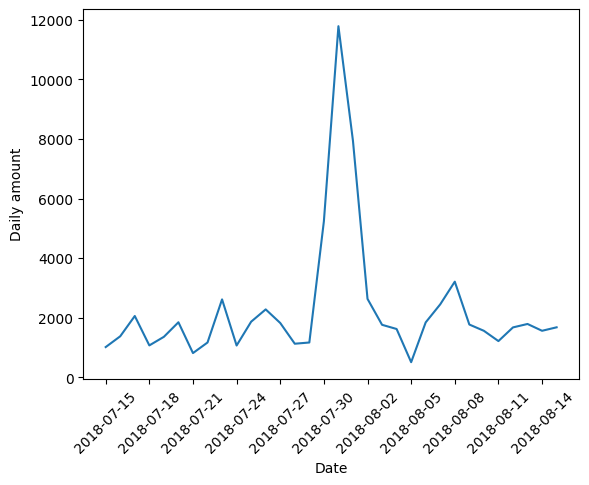

In [18]:
big_promotion_df = execute_query_to_dataframe(conn, read_sql_file_to_string('discounts_sql/anomalies_daily_sum.sql'))
make_chart(dataframe=big_promotion_df, x_column='dt', y_column='sum_amount', xlabel='Date', ylabel='Daily amount', xticks=3, xticks_rotation=45)

# General observation
---
- On average, discounts increase the payment amount, but the impact depends on the category of customers.
- For new customers, the discount percentage needs to be reduced to avoid a decrease in the average amount.
- Need more research for the case to add new licenses. Is it really free?